# Netflix Dataset Analysis

Full project notebook (cleaning, EDA, visualizations, insights, recommendations).

In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)


In [2]:
# Load dataset
csv_path = r"Netflix Dataset.csv"
df = pd.read_csv(csv_path)
# Normalize column names
df.columns = [c.strip() for c in df.columns]
df.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [3]:
# Quick overview
print('Shape:', df.shape)
df.info()

# Basic descriptive stats for numeric columns
df.describe(include='all')

Shape: (7789, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Show_Id       7789 non-null   object
 1   Category      7789 non-null   object
 2   Title         7789 non-null   object
 3   Director      5401 non-null   object
 4   Cast          7071 non-null   object
 5   Country       7282 non-null   object
 6   Release_Date  7779 non-null   object
 7   Rating        7782 non-null   object
 8   Duration      7789 non-null   object
 9   Type          7789 non-null   object
 10  Description   7789 non-null   object
dtypes: object(11)
memory usage: 669.5+ KB


,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
count,7789,7789,7789,5401,7071,7282,7779,7782,7789,7789,7789
unique,7787,2,7787,4050,6831,681,1565,14,216,492,7769
top,s6621,Movie,The Lost Okoroshi,"Raúl Campos, Jan Suter",David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,Documentaries,Multiple women report their husbands as missin...
freq,2,5379,2,18,18,2556,118,2865,1608,334,3


## Data cleaning
- Trim whitespace from string columns
- Fill obvious NaNs or drop when necessary
- Parse dates where possible


In [4]:
# Cleaning steps (examples)
# Trim strings
for c in df.select_dtypes(include=['object']).columns:
    df[c] = df[c].astype(str).str.strip()

# Attempt to coerce a 'release_year' column to int if present
for candidate in ['release_year','Year','Release Year','release year']:
    if candidate in df.columns:
        df['release_year'] = pd.to_numeric(df[candidate], errors='coerce').astype('Int64')
        break

# Create a 'title_lower' helper
if 'title' in df.columns:
    df['title_lower'] = df['title'].str.lower()

print('After cleaning shape:', df.shape)
df.head()

After cleaning shape: (7789, 11)


,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,nan,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


## EDA: Content type (Movies vs TV Shows)

Type
Documentaries                                       334
Stand-Up Comedy                                     321
Dramas, International Movies                        320
Comedies, Dramas, International Movies              243
Dramas, Independent Movies, International Movies    215
Kids' TV                                            205
Children & Family Movies                            177
Documentaries, International Movies                 172
Children & Family Movies, Comedies                  169
Comedies, International Movies                      161
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_736\3595110065.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


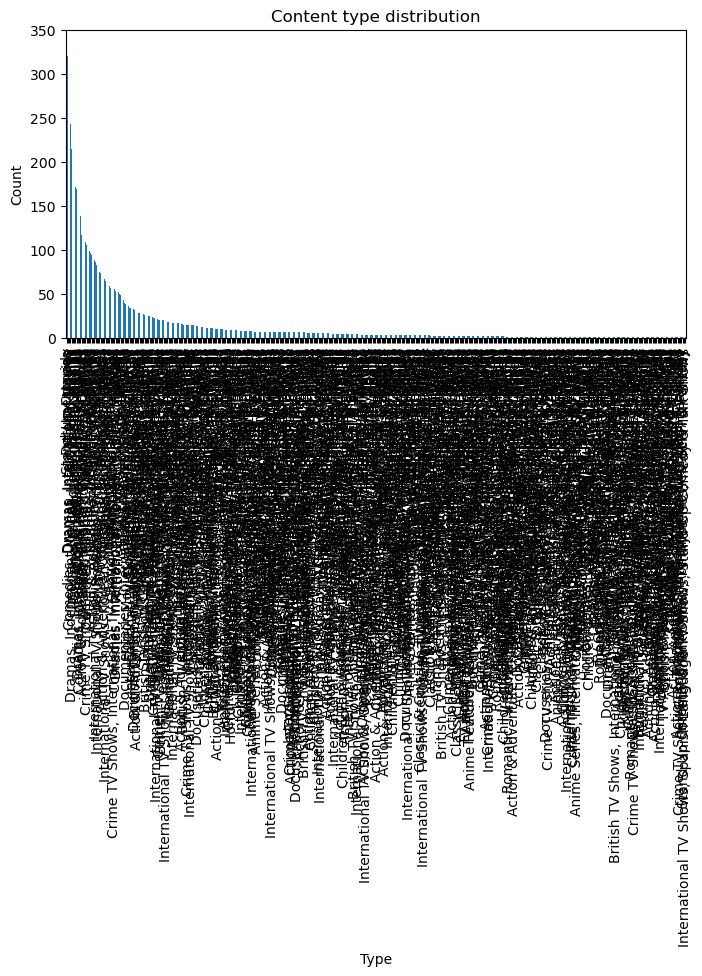

In [5]:
# Content type distribution
type_col = None
for candidate in ['type','Type','category','Category']:
    if candidate in df.columns:
        type_col = candidate
        break

if type_col:
    counts = df[type_col].fillna('Unknown').value_counts()
    print(counts.head(10))
    plt.figure(figsize=(8,4))
    counts.plot.bar()
    plt.title('Content type distribution')
    plt.xlabel(type_col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print('No obvious type column found in dataset')

## EDA: Genres / Categories
Assumes a column like `listed_in`, `genres`, or `Category` with comma-separated genres.

Category
Movie      5379
TV Show    2410
Name: count, dtype: int64


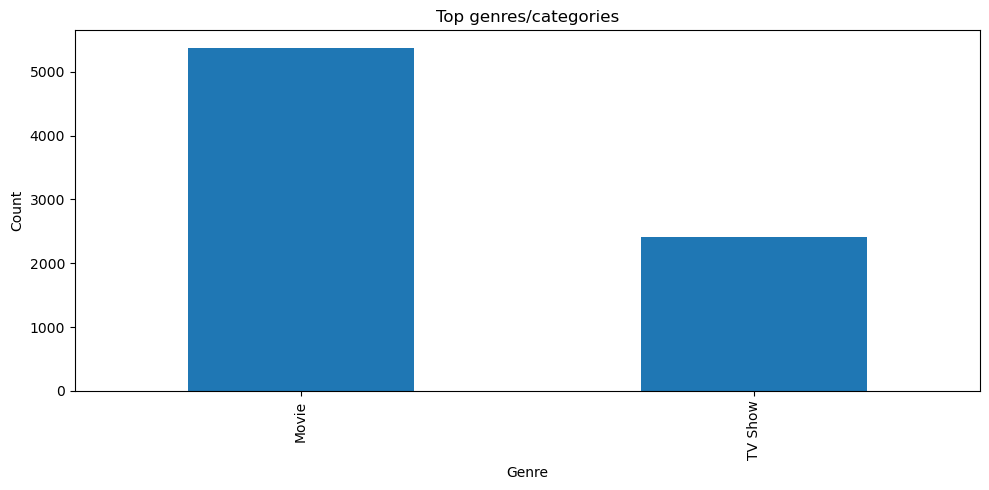

In [6]:
# Genre parsing and top genres
genre_col = None
for candidate in ['listed_in','genres','Genres','category','Category']:
    if candidate in df.columns:
        genre_col = candidate
        break

if genre_col:
    # Split comma-separated genres and explode
    genres = df[genre_col].dropna().astype(str).str.split(',')
    genres = genres.apply(lambda x: [g.strip() for g in x])
    genres_exploded = genres.explode()
    top_genres = genres_exploded.value_counts().head(20)
    print(top_genres.head(10))
    plt.figure(figsize=(10,5))
    top_genres.head(15).plot.bar()
    plt.title('Top genres/categories')
    plt.xlabel('Genre')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print('No genre-like column found')

## EDA: Country-wise contributions

Country
United States     3298
India              990
United Kingdom     723
nan                507
Canada             412
France             349
Japan              287
Spain              215
South Korea        212
Germany            199
Name: count, dtype: int64


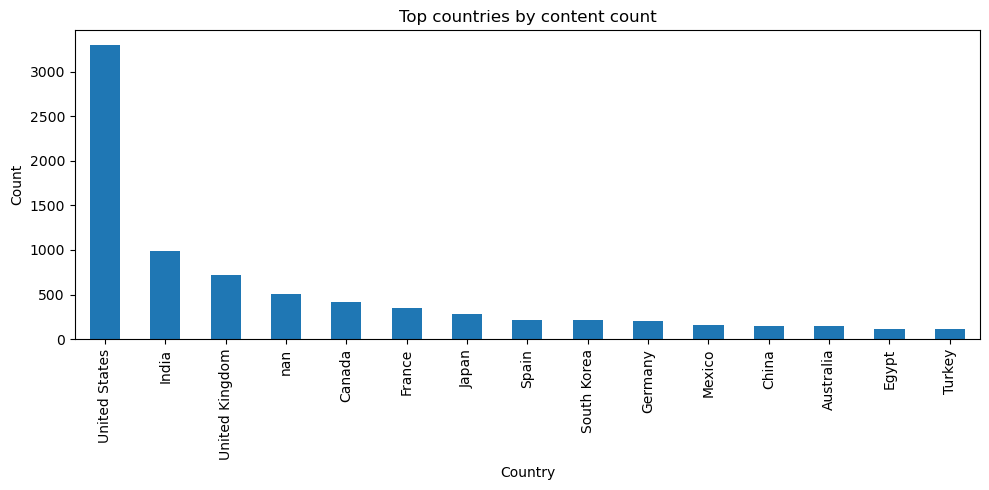

In [7]:
# Country contributions
country_col = None
for candidate in ['country','Country','countries']:
    if candidate in df.columns:
        country_col = candidate
        break

if country_col:
    countries = df[country_col].dropna().astype(str).str.split(',').apply(lambda x: [c.strip() for c in x])
    country_exploded = countries.explode()
    top_countries = country_exploded.value_counts().head(20)
    print(top_countries.head(10))
    plt.figure(figsize=(10,5))
    top_countries.head(15).plot.bar()
    plt.title('Top countries by content count')
    plt.xlabel('Country')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print('No country column found')

## EDA: Releases over time (by year)

In [8]:
# Releases by year
if 'release_year' in df.columns:
    by_year = df['release_year'].dropna().astype(int).value_counts().sort_index()
    display(by_year.head(20))
    plt.figure(figsize=(10,4))
    by_year.plot.line()
    plt.title('Number of titles released by year')
    plt.xlabel('Year')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print('No release_year column available')

No release_year column available
